In [1]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler,MinMaxScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv('C:\\Users\\Admin\\OneDrive\\Desktop\\data science\\ML\\SUPERVISED LEARNING\\Dataset\\loan_approval_dataset.csv')
X = df.drop(columns='Loan_Approved')
y = df['Loan_Approved']
df

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No
...,...,...,...,...,...,...,...,...,...
995,22,49241,500,41020,24 months,Self-Employed,Owned,No,Yes
996,40,116214,423,12415,48 months,Self-Employed,Owned,No,Yes
997,27,64569,300,28155,36 months,Self-Employed,Rented,Yes,Yes
998,61,31745,490,48884,12 months,Self-Employed,Mortgage,No,Yes


<Axes: >

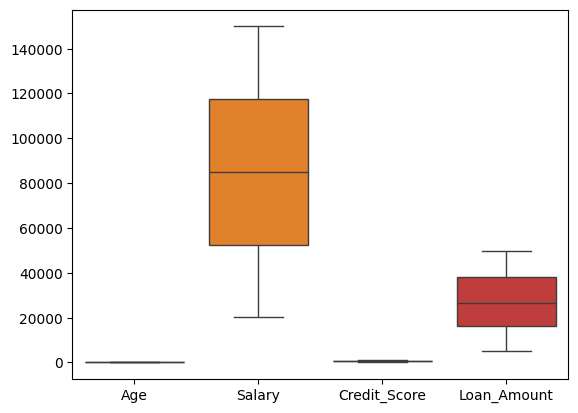

In [3]:
import seaborn as sns
sns.boxplot(X)

In [4]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,train_size=0.8,random_state=42)

In [5]:
y.value_counts()

Loan_Approved
Yes    508
No     492
Name: count, dtype: int64

In [6]:
num_cols = X.select_dtypes(include='number').columns
obj_cols = X.select_dtypes(include='object').columns

C:\Users\Admin\AppData\Local\Temp\ipykernel_9068\2146109923.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = X.select_dtypes(include='object').columns


In [7]:
preprocessing = ColumnTransformer(
    transformers=[
        ('scaling',StandardScaler(),num_cols),
        ('encoder',OneHotEncoder(),obj_cols)
    ]
)

main_pipe = Pipeline(
    steps=[
        ('pre',preprocessing),
        ('model',KNeighborsClassifier())
    ]
)
# main_pipe.fit(xtrain,ytrain)

In [ ]:
grid_cv = GridSearchCV(
    estimator=main_pipe,
    param_grid={
        'model__n_neighbors' :[3,7,25,27,29,31],
        'model__metric':['manhattan','euclidean']
    },
    cv=5,
    n_jobs=-1
)
grid_cv.fit(xtrain,ytrain)

In [ ]:
res = grid_cv.cv_results_
pd.DataFrame(res)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__metric,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.080912,0.022969,0.077232,0.020272,manhattan,3,"{'model__metric': 'manhattan', 'model__n_neigh...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
1,0.097594,0.027675,0.064085,0.011642,manhattan,7,"{'model__metric': 'manhattan', 'model__n_neigh...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
2,0.105404,0.016252,0.056939,0.009451,manhattan,25,"{'model__metric': 'manhattan', 'model__n_neigh...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
3,0.055634,0.016915,0.025431,0.001659,manhattan,27,"{'model__metric': 'manhattan', 'model__n_neigh...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
4,0.043233,0.001350,0.030878,0.006280,manhattan,29,"{'model__metric': 'manhattan', 'model__n_neigh...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
5,0.043986,0.006625,0.030335,0.004390,manhattan,31,"{'model__metric': 'manhattan', 'model__n_neigh...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
6,0.047764,0.008816,0.035852,0.012389,euclidean,3,"{'model__metric': 'euclidean', 'model__n_neigh...",0.48750,0.53125,0.51875,0.56250,0.45000,0.51000,0.038446,1
7,0.058646,0.013687,0.032455,0.003515,euclidean,7,"{'model__metric': 'euclidean', 'model__n_neigh...",0.46250,0.46875,0.48125,0.51250,0.41250,0.46750,0.032452,6
8,0.043938,0.004265,0.030261,0.001916,euclidean,25,"{'model__metric': 'euclidean', 'model__n_neigh...",0.42500,0.48125,0.55625,0.49375,0.45000,0.48125,0.044546,3
9,0.041769,0.003171,0.030854,0.001343,euclidean,27,"{'model__metric': 'euclidean', 'model__n_neigh...",0.43750,0.45625,0.58750,0.49375,0.44375,0.48375,0.055424,2


In [ ]:
grid_cv.best_params_

{'model__metric': 'euclidean', 'model__n_neighbors': 3}